# EDA - Actividades económicas de San Fernando

Se realiza un análisis exploratorio simple de la base de actividades económicas ACT de SERNATUR. 
El análisis se concentra en **San Fernando** y utiliza **2023**, que corresponde al último año disponible en la fuente.
La estructura del EDA toma como referencia el notebook de la encuesta de Vendimia, manteniendo un enfoque simple y progresivo.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 1. Carga y filtro de la base

La base original contiene información comunal para distintos años. Para este análisis se trabaja únicamente con registros de San Fernando correspondientes al año comercial 2023.


In [2]:
file_id_encuesta = "1o1lp7bbChpzDCOPK0fUWyKxNnvd7_Hwz"
url = f"https://drive.google.com/uc?id={file_id_encuesta}"

ventas_actividad = pd.read_csv(
    url,
    sep=";",
    engine="python"
)

ventas_actividad = ventas_actividad[
    (ventas_actividad["Año Comercial"] == 2023) &
    (
        ventas_actividad["Comuna del domicilio o casa matriz"]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("san fernando")
    )
].copy()

ventas_actividad.head()


,Año Comercial,Region del domicilio o casa matriz,Provincia del domicilio o casa matriz,Comuna del domicilio o casa matriz,Actividad economica,Glosa actividad economica,Número de empresas,Ventas anuales en UF,Trabajadores dependientes informados ponderados,Renta neta informada,Trabajadores a honorarios ponderados por meses trabajados,Honorarios pagados informados,COD_ACT,ACT,CUT_comuna,ACT Prioritaria,Unnamed: 16
83922,2023,Región del Libertador Gral. Bernardo O’Higgins,Colchagua,San Fernando,551001,Actividades de hoteles,22.0,"77.714,64","101,833","15715,089","13,833","1465,054",1,Alojamiento turístico,6301,SI,NaN
83923,2023,Región del Libertador Gral. Bernardo O’Higgins,Colchagua,San Fernando,551002,Actividades de moteles,1.0,*,"1,25",*,"0,417",*,1,Alojamiento turístico,6301,SI,NaN
83924,2023,Región del Libertador Gral. Bernardo O’Higgins,Colchagua,San Fernando,551003,Actividades de residenciales para turistas,4.0,*,"2,25",*,1,*,1,Alojamiento turístico,6301,SI,NaN
83925,2023,Región del Libertador Gral. Bernardo O’Higgins,Colchagua,San Fernando,551009,Otras actividades de alojamiento para turistas...,4.0,*,"1,5",*,"1,917",*,1,Alojamiento turístico,6301,SI,NaN
83926,2023,Región del Libertador Gral. Bernardo O’Higgins,Colchagua,San Fernando,559001,Actividades de residenciales para estudiantes ...,19.0,"7.374,61","5,833","681,225",6,"217,457",1,Alojamiento turístico,6301,NO,NaN


In [3]:
# Revisar las columnas disponibles
ventas_actividad.columns


Index(['Año Comercial', 'Region del domicilio o casa matriz',
       'Provincia del domicilio o casa matriz',
       'Comuna del domicilio o casa matriz', 'Actividad economica',
       'Glosa actividad economica', 'Número de empresas',
       'Ventas anuales en UF',
       'Trabajadores dependientes informados ponderados',
       'Renta neta informada',
       'Trabajadores a honorarios ponderados por meses trabajados',
       'Honorarios pagados informados', 'COD_ACT', 'ACT', 'CUT_comuna',
       'ACT Prioritaria', 'Unnamed: 16'],
      dtype='str')

In [4]:
# Revisar cantidad de filas y columnas
ventas_actividad.shape


(34, 17)

In [5]:
# Revisar tipos de datos y valores no nulos
ventas_actividad.info()


<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 83922 to 83955
Data columns (total 17 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   Año Comercial                                              34 non-null     int64  
 1   Region del domicilio o casa matriz                         34 non-null     str    
 2   Provincia del domicilio o casa matriz                      34 non-null     str    
 3   Comuna del domicilio o casa matriz                         34 non-null     str    
 4   Actividad economica                                        34 non-null     int64  
 5   Glosa actividad economica                                  34 non-null     str    
 6   Número de empresas                                         34 non-null     float64
 7   Ventas anuales en UF                                       34 non-null     str    
 8   Trabajadores dep

**Observación.** Luego del filtro, la base contiene **34 registros** y **17 columnas**. Todas las filas corresponden a San Fernando y al año comercial 2023. La columna `Unnamed: 16` no contiene información y será eliminada.


La revisión inicial permite conocer la estructura de la base filtrada e identificar qué variables necesitan limpieza antes del análisis descriptivo.


## 2. Calidad y limpieza de datos


In [6]:
# Revisar valores faltantes por columna
ventas_actividad.isna().sum().sort_values(ascending=False)


Unnamed: 16                                                  34
Año Comercial                                                 0
Region del domicilio o casa matriz                            0
Comuna del domicilio o casa matriz                            0
Provincia del domicilio o casa matriz                         0
Glosa actividad economica                                     0
Número de empresas                                            0
Ventas anuales en UF                                          0
Actividad economica                                           0
Trabajadores dependientes informados ponderados               0
Renta neta informada                                          0
Honorarios pagados informados                                 0
Trabajadores a honorarios ponderados por meses trabajados     0
COD_ACT                                                       0
ACT                                                           0
CUT_comuna                              

In [7]:
# Eliminar columna residual si se encuentra completamente vacía
if "Unnamed: 16" in ventas_actividad.columns:
    ventas_actividad = ventas_actividad.drop(columns=["Unnamed: 16"])


In [8]:
# Revisar filas duplicadas
ventas_actividad.duplicated().sum()


np.int64(0)

**Cierre de calidad básica.** No se identificaron filas duplicadas. Tampoco existen valores nulos en las variables originales relevantes; la única columna completamente vacía era `Unnamed: 16`, que corresponde a un residuo del archivo.


Se revisan además valores especiales en variables que deberían ser numéricas. En esta base, algunas variables económicas utilizan `*`, por lo que no se interpretan directamente como números.


In [9]:
columnas_numericas_texto = [
    "Ventas anuales en UF",
    "Trabajadores dependientes informados ponderados",
    "Renta neta informada",
    "Trabajadores a honorarios ponderados por meses trabajados",
    "Honorarios pagados informados"
]

for col in columnas_numericas_texto:
    valores_no_numericos = ventas_actividad[
        pd.to_numeric(
            ventas_actividad[col]
            .astype(str)
            .str.replace(".", "", regex=False)
            .str.replace(",", ".", regex=False),
            errors="coerce"
        ).isna()
    ][col].value_counts()

    print(f"\n{col}:")
    print(valores_no_numericos.head(10))



Ventas anuales en UF:
Ventas anuales en UF
*    20
Name: count, dtype: int64

Trabajadores dependientes informados ponderados:
Series([], Name: count, dtype: int64)

Renta neta informada:
Renta neta informada
*    20
Name: count, dtype: int64

Trabajadores a honorarios ponderados por meses trabajados:
Series([], Name: count, dtype: int64)

Honorarios pagados informados:
Honorarios pagados informados
*    20
Name: count, dtype: int64


**Observación sobre valores especiales.** Se identificó el símbolo `*` en **20 de los 34 registros** para `Ventas anuales en UF`, `Renta neta informada` y `Honorarios pagados informados`. Esto significa que estas tres variables económicas solo cuentan con valores numéricos publicados en **14 registros**.

Por lo tanto, los análisis basados en ventas, renta y honorarios deben interpretarse sobre ese subconjunto disponible y no como una representación completa de las 34 actividades.


Los valores `*` se mantienen en las columnas originales. Para poder analizar las variables económicas se crean versiones numéricas, transformando temporalmente esos casos en `NaN`.


In [10]:
columnas_convertir = [
    "Número de empresas",
    "Trabajadores dependientes informados ponderados",
    "Trabajadores a honorarios ponderados por meses trabajados"
]

for col in columnas_convertir:
    ventas_actividad[col] = (
        ventas_actividad[col]
        .astype(str)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
    )

    ventas_actividad[col] = pd.to_numeric(
        ventas_actividad[col],
        errors="coerce"
    )


In [11]:
columnas_con_asterisco = [
    "Ventas anuales en UF",
    "Renta neta informada",
    "Honorarios pagados informados"
]

for col in columnas_con_asterisco:
    ventas_actividad[col + "_num"] = (
        ventas_actividad[col]
        .replace("*", np.nan)
        .astype(str)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
    )

    ventas_actividad[col + "_num"] = pd.to_numeric(
        ventas_actividad[col + "_num"],
        errors="coerce"
    )


In [12]:
# Verificar los tipos finales de las variables usadas en el análisis
ventas_actividad[
    [
        "Número de empresas",
        "Ventas anuales en UF_num",
        "Trabajadores dependientes informados ponderados",
        "Renta neta informada_num",
        "Trabajadores a honorarios ponderados por meses trabajados",
        "Honorarios pagados informados_num"
    ]
].dtypes


Número de empresas                                             int64
Ventas anuales en UF_num                                     float64
Trabajadores dependientes informados ponderados              float64
Renta neta informada_num                                     float64
Trabajadores a honorarios ponderados por meses trabajados    float64
Honorarios pagados informados_num                            float64
dtype: object

Las variables necesarias para el análisis quedaron correctamente convertidas a formato numérico. Las columnas originales con `*` se conservaron y se crearon versiones `_num` para trabajar estadísticamente sin perder la codificación original.


## 3. Revisión descriptiva general

Se revisan medidas básicas de las variables cuantitativas para conocer su rango, tendencia central y dispersión.


In [13]:
variables_analisis = [
    "Número de empresas",
    "Ventas anuales en UF_num",
    "Trabajadores dependientes informados ponderados",
    "Renta neta informada_num",
    "Trabajadores a honorarios ponderados por meses trabajados",
    "Honorarios pagados informados_num"
]

ventas_actividad[variables_analisis].describe().T


,count,mean,std,min,25%,50%,75%,max
Número de empresas,34.0,228.529412,503.130397,10.000,30.00000,55.0000,200.00000,2790.000
Ventas anuales en UF_num,14.0,77942.112857,118453.213473,5134.540,11375.65500,31863.7800,79070.04750,434482.300
Trabajadores dependientes informados ponderados,34.0,25.031853,74.994760,0.000,1.00000,2.7085,13.10450,426.333
Renta neta informada_num,14.0,9095.789929,16087.887106,124.234,1640.50750,2897.3415,8350.87050,61024.760
Trabajadores a honorarios ponderados por meses trabajados,34.0,5.958382,13.020953,0.000,0.43775,1.4165,5.87500,70.417
Honorarios pagados informados_num,14.0,1412.930786,2494.386731,0.000,227.52450,740.5380,1049.68975,9583.831


In [14]:
# Media, mediana y desviación estándar
resumen = pd.DataFrame({
    "media": ventas_actividad[variables_analisis].mean(),
    "mediana": ventas_actividad[variables_analisis].median(),
    "desviacion_std": ventas_actividad[variables_analisis].std()
})

resumen.round(2)


,media,mediana,desviacion_std
Número de empresas,228.53,55.00,503.13
Ventas anuales en UF_num,77942.11,31863.78,118453.21
Trabajadores dependientes informados ponderados,25.03,2.71,74.99
Renta neta informada_num,9095.79,2897.34,16087.89
Trabajadores a honorarios ponderados por meses trabajados,5.96,1.42,13.02
Honorarios pagados informados_num,1412.93,740.54,2494.39


**Lectura descriptiva.** Todas las variables presentan medias mayores que sus medianas. Esto indica que algunos registros con valores altos elevan los promedios.

Por ejemplo, el número de empresas presenta una media de aproximadamente **229 empresas**, mientras que la mediana es de **55**. En ventas anuales, considerando solo los 14 registros con información publicada, la media es cercana a **77.942 UF** y la mediana a **31.864 UF**.


Las diferencias entre media y mediana permiten identificar si algunas variables están influenciadas por actividades con valores particularmente altos.


In [15]:
# Revisar asimetría de las variables numéricas
ventas_actividad[variables_analisis].skew().round(2)


Número de empresas                                           4.41
Ventas anuales en UF_num                                     2.51
Trabajadores dependientes informados ponderados              4.97
Renta neta informada_num                                     2.97
Trabajadores a honorarios ponderados por meses trabajados    4.16
Honorarios pagados informados_num                            3.12
dtype: float64

**Forma de las distribuciones.** Todas las variables presentan asimetría positiva. Los valores más altos se observan en trabajadores dependientes (`4,97`), número de empresas (`4,41`) y trabajadores a honorarios (`4,16`), lo que confirma que existen pocas actividades con valores considerablemente superiores al resto.


## 4. Actividades económicas presentes en San Fernando

Se revisa la composición de actividades económicas para entender qué tipos de actividades aparecen con mayor frecuencia en la comuna.


In [16]:
# Conteo de grandes grupos ACT
ventas_actividad["ACT"].value_counts()


ACT
Actividades deportivas y recreativas                                  7
Alojamiento turístico                                                 6
Transporte de pasajeros por carretera                                 6
Actividades culturales                                                4
Actividades de provisión de alimentos y bebidas                       3
Actividades relacionadas con segundos hogares y multipropiedades      3
Actividades de agencias de viajes y de otros servicios de reservas    2
Transporte de pasajeros por agua                                      1
Alquiler de equipos de transporte                                     1
Comercio al por menor de bienes característicos del turismo           1
Name: count, dtype: int64

**Composición de actividades.** Las categorías con mayor número de registros son `Actividades deportivas y recreativas` (7), `Alojamiento turístico` (6) y `Transporte de pasajeros por carretera` (6). Estas tres categorías concentran más de la mitad de las actividades observadas en la base filtrada.


In [17]:
# Revisar actividades prioritarias
ventas_actividad["ACT Prioritaria"].value_counts()


ACT Prioritaria
SI    29
NO     5
Name: count, dtype: int64

De los 34 registros, **29 están clasificados como ACT Prioritaria** y 5 como no prioritarios. Esto muestra que la mayor parte de las actividades presentes en la base filtrada pertenece a categorías consideradas prioritarias dentro de la clasificación utilizada.


In [18]:
# Actividades con mayor número de empresas
ventas_actividad.nlargest(
    10,
    "Número de empresas"
)[
    [
        "Glosa actividad economica",
        "ACT",
        "Número de empresas"
    ]
]


,Glosa actividad economica,ACT,Número de empresas
83928,Actividades de restaurantes y de servicio móvi...,Actividades de provisión de alimentos y bebidas,2790
83954,"Compra, venta y alquiler (excepto amoblados) d...",Actividades relacionadas con segundos hogares ...,1130
83932,Servicios de transporte de trabajadores,Transporte de pasajeros por carretera,610
83936,Otras actividades de transporte de pasajeros p...,Transporte de pasajeros por carretera,450
83929,Suministro industrial de comidas por encargo; ...,Actividades de provisión de alimentos y bebidas,310
83953,Alquiler de bienes inmuebles amoblados o con e...,Actividades relacionadas con segundos hogares ...,230
83955,Actividades inmobiliarias realizadas a cambio ...,Actividades relacionadas con segundos hogares ...,230
83922,Actividades de hoteles,Alojamiento turístico,220
83931,Servicios de transporte de escolares,Transporte de pasajeros por carretera,200
83951,Otras actividades de esparcimiento y recreativ...,Actividades deportivas y recreativas,200


**Actividades con mayor número de empresas.** Destaca ampliamente `Actividades de restaurantes y de servicio móvil de comidas`, con **2.790 empresas**. Le siguen actividades asociadas a segundos hogares y multipropiedades, además de distintas actividades de transporte.

Esta concentración ayuda a identificar qué actividades tienen mayor presencia empresarial dentro de San Fernando.


## 5. Ventas y actividad económica

Para los registros que cuentan con información disponible de ventas, se revisan las actividades con mayores ventas anuales en UF.


In [19]:
ventas_actividad.nlargest(
    10,
    "Ventas anuales en UF_num"
)[
    [
        "Glosa actividad economica",
        "ACT",
        "Número de empresas",
        "Ventas anuales en UF_num"
    ]
]


,Glosa actividad economica,ACT,Número de empresas,Ventas anuales en UF_num
83928,Actividades de restaurantes y de servicio móvi...,Actividades de provisión de alimentos y bebidas,2790,434482.30
83954,"Compra, venta y alquiler (excepto amoblados) d...",Actividades relacionadas con segundos hogares ...,1130,227002.84
83936,Otras actividades de transporte de pasajeros p...,Transporte de pasajeros por carretera,450,99447.70
83953,Alquiler de bienes inmuebles amoblados o con e...,Actividades relacionadas con segundos hogares ...,230,79521.85
83922,Actividades de hoteles,Alojamiento turístico,220,77714.64
83932,Servicios de transporte de trabajadores,Transporte de pasajeros por carretera,610,44100.68
83929,Suministro industrial de comidas por encargo; ...,Actividades de provisión de alimentos y bebidas,310,32452.14
83938,Alquiler de vehículos automotores sin chofer,Alquiler de equipos de transporte,190,31275.42
83951,Otras actividades de esparcimiento y recreativ...,Actividades deportivas y recreativas,200,22105.67
83927,Otras actividades de alojamiento n.c.p.,Alojamiento turístico,150,14558.94


**Actividades con mayores ventas publicadas.** Entre los registros con información disponible, `Actividades de restaurantes y de servicio móvil de comidas` presenta el mayor valor de ventas anuales, con aproximadamente **434.482 UF**. Le siguen actividades relacionadas con compra, venta y alquiler de inmuebles, con aproximadamente **227.003 UF**.

Es importante recordar que este ranking considera únicamente registros con ventas publicadas; 20 actividades presentan `*` y no participan en esta comparación.


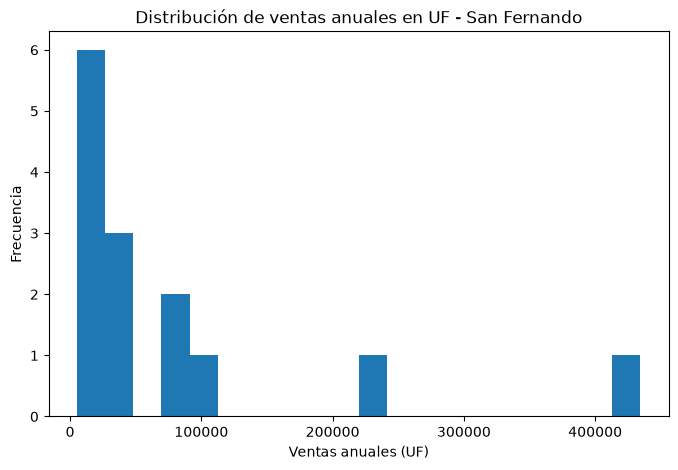

In [20]:
plt.figure(figsize=(8, 5))

plt.hist(
    ventas_actividad["Ventas anuales en UF_num"].dropna(),
    bins=20
)

plt.title("Distribución de ventas anuales en UF - San Fernando")
plt.xlabel("Ventas anuales (UF)")
plt.ylabel("Frecuencia")

plt.show()


El histograma evidencia una distribución concentrada en valores relativamente bajos y una cola hacia la derecha, consistente con la asimetría calculada previamente. Un pequeño número de actividades concentra niveles de ventas considerablemente superiores.


El histograma permite observar si las ventas se concentran en rangos bajos o si existen algunas actividades con valores considerablemente superiores al resto.


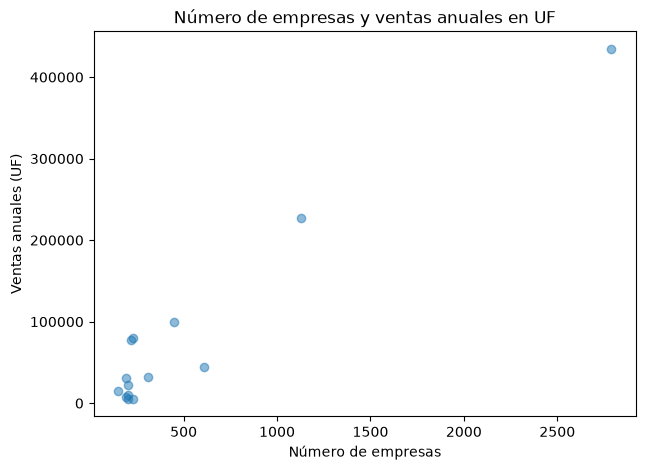

In [21]:
# Comparar número de empresas y ventas anuales
plt.figure(figsize=(7, 5))

plt.scatter(
    ventas_actividad["Número de empresas"],
    ventas_actividad["Ventas anuales en UF_num"],
    alpha=0.5
)

plt.title("Número de empresas y ventas anuales en UF")
plt.xlabel("Número de empresas")
plt.ylabel("Ventas anuales (UF)")

plt.show()


El gráfico permite observar una relación positiva entre el número de empresas y las ventas anuales publicadas: en general, las actividades con mayor cantidad de empresas tienden a presentar mayores ventas. Sin embargo, la dispersión muestra que el número de empresas por sí solo no explica completamente las diferencias de ventas entre actividades.


## 6. Relación entre variables económicas

Se calcula una matriz de correlación simple como apoyo descriptivo. Debido a la asimetría observada, Spearman puede ser más útil que Pearson para revisar relaciones monotónicas entre las variables.


In [22]:
corr_spearman = ventas_actividad[variables_analisis].corr(method="spearman")

corr_spearman.round(2)


,Número de empresas,Ventas anuales en UF_num,Trabajadores dependientes informados ponderados,Renta neta informada_num,Trabajadores a honorarios ponderados por meses trabajados,Honorarios pagados informados_num
Número de empresas,1.00,0.72,0.76,0.57,0.71,0.31
Ventas anuales en UF_num,0.72,1.00,0.84,0.78,0.63,0.67
Trabajadores dependientes informados ponderados,0.76,0.84,1.00,0.95,0.81,0.71
Renta neta informada_num,0.57,0.78,0.95,1.00,0.75,0.78
Trabajadores a honorarios ponderados por meses trabajados,0.71,0.63,0.81,0.75,1.00,0.75
Honorarios pagados informados_num,0.31,0.67,0.71,0.78,0.75,1.00


**Relaciones entre variables.** La matriz de Spearman muestra asociaciones positivas en la mayoría de las variables. Destacan:

- ventas anuales y trabajadores dependientes: **0,84**;
- renta neta y trabajadores dependientes: **0,95**;
- ventas anuales y renta neta: **0,78**;
- número de empresas y trabajadores dependientes: **0,76**.

Estas relaciones indican que las actividades de mayor escala tienden a presentar simultáneamente más trabajadores, mayores ventas y mayor renta. De todas formas, las correlaciones que involucran ventas, renta u honorarios se calculan sobre solo **14 registros con información publicada**, por lo que deben interpretarse como evidencia descriptiva y no como conclusiones generales.


## 7. Cobertura de información económica

Antes de cerrar el análisis, se cuantifica explícitamente la proporción de registros que cuentan con información publicada de ventas. Esto permite dimensionar la principal limitación de la fuente.


In [ ]:
# Cobertura de información de ventas
total_registros = len(ventas_actividad)
con_ventas = ventas_actividad["Ventas anuales en UF_num"].notna().sum()
sin_ventas = ventas_actividad["Ventas anuales en UF_num"].isna().sum()

cobertura_ventas = pd.DataFrame({
    "Registros": [con_ventas, sin_ventas],
    "Porcentaje": [
        con_ventas / total_registros * 100,
        sin_ventas / total_registros * 100
    ]
}, index=["Con ventas publicadas", "Sin ventas publicadas"])

cobertura_ventas.round(2)


Con los resultados ya observados en el EDA, se espera una cobertura de **14 registros con ventas publicadas (41,2%)** y **20 registros sin ventas publicadas (58,8%)**. Esta limitación debe mantenerse presente en cualquier comparación económica posterior.


## 8. Empresas por categoría ACT

Como complemento al conteo de registros por categoría, se propone sumar el número de empresas dentro de cada grupo ACT. Esto permite diferenciar entre una categoría que aparece muchas veces y una categoría que realmente concentra un mayor número de empresas.


In [ ]:
empresas_por_act = (
    ventas_actividad
    .groupby("ACT")["Número de empresas"]
    .sum()
    .sort_values(ascending=False)
)

empresas_por_act


In [ ]:
plt.figure(figsize=(9, 5))

empresas_por_act.sort_values().plot(kind="barh")

plt.title("Número de empresas por categoría ACT - San Fernando")
plt.xlabel("Número de empresas")
plt.ylabel("Categoría ACT")
plt.tight_layout()

plt.show()


## 9. Cierre del EDA

El análisis muestra una estructura económica heterogénea en San Fernando. Algunas actividades concentran un número de empresas y niveles de ventas muy superiores al resto, destacando especialmente las actividades de restaurantes y servicios móviles de comida.

También se observa una relación positiva entre escala empresarial, empleo, ventas y renta neta. Sin embargo, la principal limitación de esta fuente es la disponibilidad parcial de información económica: solo **14 de 34 registros** cuentan con ventas, renta y honorarios publicados, mientras que los otros 20 presentan el valor `*`.

Por esta razón, la base ACT debe utilizarse principalmente como **fuente complementaria de contexto económico para San Fernando**, y no como una medición directa del impacto de la Vendimia. Su aporte principal consiste en caracterizar el entorno empresarial y las actividades asociadas al turismo, alimentación, alojamiento, transporte y recreación presentes en la comuna.
